In [5]:
import pvlib
import pandas as pd
import numpy as np

# Custom Scarab Module (3S)

Photocurrent [I_L_ref]: 8.588
Saturation current [I_o_ref]: 4.333107149794063e-11
Series resistance [Rs]: 0.126
Shunt resistance [Rsh]: 103.164
a [a_ref]: 0.422
Adjust [adjust]: 5.1

Max power: 70.66 Wp


/opt/homebrew/Caskroom/miniforge/base/envs/py311/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniforge/base/envs/py311/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniforge/base/envs/py311/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/

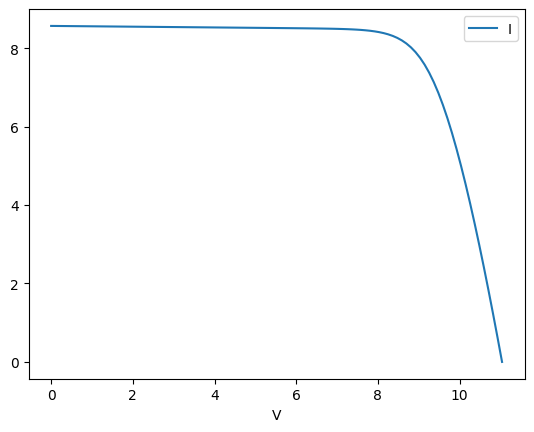

In [6]:
vmp = 8.698
imp = 8.056
voc = 10.965
isc = 8.493
alphasc = 0.06 / 100 * isc # convert %/K to A/K
betavoc = -0.3 / 100 * voc # convert %/K to V/K
gammapmp = -0.39
Ns = 16
T_c_ref = 22.8

IL, Io, Rs, Rsh, a, adjust = pvlib.ivtools.sdm.fit_cec_sam("monoSi", 
                              vmp, imp,
                              voc, isc, 
                              alphasc, betavoc, gammapmp,
                              Ns, temp_ref=T_c_ref)

print(f"Photocurrent [I_L_ref]: {round(IL,3)}\n"
      f"Saturation current [I_o_ref]: {Io}\n"
      f"Series resistance [Rs]: {round(Rs,3)}\n"
      f"Shunt resistance [Rsh]: {round(Rsh,3)}\n"
      f"a [a_ref]: {round(a,3)}\n"
      f"Adjust [adjust]: {round(adjust,3)}\n")

IL, I0, Rs, Rsh, nNsVth = pvlib.pvsystem.calcparams_desoto(
    1000,
    T_c_ref,
    alpha_sc=alphasc,
    a_ref=a,
    I_L_ref=IL,
    I_o_ref=Io,
    R_sh_ref=Rsh,
    R_s=Rs,
    EgRef=1.121,
    dEgdT=-0.0002677
)
SDE_params = {
    'photocurrent': IL,
    'saturation_current': I0,
    'resistance_series': Rs,
    'resistance_shunt': Rsh,
    'nNsVth': nNsVth
}
curve_info = pvlib.pvsystem.singlediode(method='lambertw', **SDE_params)
v = pd.Series(np.linspace(0., curve_info['v_oc'], 100)).rename("V")
i = pd.Series(pvlib.pvsystem.i_from_v(voltage=v, method='lambertw', **SDE_params)).rename("I")


pd.concat([v,i],axis=1).plot(x='V',y='I')

v_mp = curve_info['v_mp']
i_mp = curve_info['i_mp']
pmp = i_mp * v_mp
print(f"Max power: {round(pmp,2)} Wp")

In [11]:
area_module_m2 = 0.53025
mod_efficiency = pmp / (1000 * area_module_m2)

area_cell_m2 = (.210 * .105) * Ns
cell_efficiency = pmp / (1000 * area_cell_m2)
cell_efficiency

0.20027439544830128

In [ ]:
# create the map